In [1]:
import os
import sys
import time
import requests
# Azure storage configuration
import fsspec
import duckdb

sys.path.append('/home/potzschf/repos/')

from shapely.geometry import box
from pathlib import Path
import pystac
import rioxarray
from stac_geoparquet.arrow._api import stac_table_to_items
import odc.stac
import xarray as xr
import numpy as np
import pandas as pd

from FieldWaterUseTools.FuncBox.Misc import getFilelist, is_leap_year, npTOdisk, path_safe, slash_checker, download_thuenen_cropTypes, stackReader # FieldWaterUseTools.FuncBox.
from FieldWaterUseTools.FuncBox.DICT_LIST import DAYCOUNT_LEAP, DAYCOUNT_NOLEAP, INT_TO_MONTH, REAL_INT_TO_MONTH # FieldWaterUseTools.FuncBox.

def get_query(start_date, end_date, wkt_bbox, stac_geoparquet):
    """Generate SQL query for filtering STAC items by date and geometry."""
    sql_where = f'(("datetime" BETWEEN \'{start_date}T00:00:00Z\' AND \'{end_date}T23:59:59Z\')) AND (ST_Intersects(geometry, ST_GeomFromText(\'{wkt_bbox}\')) )'
    sql_query = f"SELECT * EXCLUDE(geometry),ST_AsWKB(geometry) as geometry FROM read_parquet('{stac_geoparquet}', union_by_name=False) WHERE {sql_where}"
    return sql_query

def add_sas_token(item, sas_token):
    """Add SAS token to all asset URLs in a STAC item."""
    for _, asset in item.assets.items():
        asset.href = f"{asset.href}?{sas_token}"
    return item

In [5]:
# set year and month for which to obtain data
YEAR = 2026
MONTH = 5

# set masterpath for stored data
origin = slash_checker("/data/Aldhani/eoagritwin/et/")
storPath_master = slash_checker(path_safe(f"{origin}etZ_REPO_TEST/"))#'/place/to/store/porducts/')
storPath_S3 = slash_checker(path_safe(f"{storPath_master}{YEAR}/{MONTH:02d}/S3/"))
AirTemp_path = slash_checker(f"{origin}Auxiliary/ERA5/tiff/low_res_rss/2m_temperature/")

################################################################### Sentinel-3 compositing
#set paths
path_to_S3_composites = path_safe(f"{storPath_master}Sentinel3/")
LST_path = f"{path_to_S3_composites}LST/"
VZA_path = f"{path_to_S3_composites}VZA/"
VAA_path = f"{path_to_S3_composites}VAA/"

LST_maxLST_path = path_safe(f"{LST_path}maxLST/{YEAR}/")
VZA_maxLST_path = path_safe(f"{VZA_path}maxLST/{YEAR}/")
VAA_maxLST_path = path_safe(f"{VAA_path}maxLST/{YEAR}/")

AcqTime_stor_path = path_safe(f"{path_to_S3_composites}Acq_Time/{YEAR}/")

# Define bounding box and time frame for Germany for S3 compositing
bbox = [5.592041, 47.129951, 15.26001, 55.09723]  # Germany
bbox_shape = box(*bbox)
wkt_bbox = bbox_shape.wkt

start = f"{YEAR}-{MONTH:02d}-01"
if is_leap_year(YEAR):
   end = f"{YEAR}-{MONTH:02d}-{DAYCOUNT_LEAP[MONTH-1]}"
else:
    end = f"{YEAR}-{MONTH:02d}-{DAYCOUNT_NOLEAP[MONTH-1]}"

# read AZURE CLOUD KEY from file in personal folder
with open ('/data/Aldhani/users/potzschf/rss.txt') as f:
    STORAGE_ACCOUNT = f.readline().strip()
    SAS_KEY = f.readline().strip()


# Setup Azure filesystem and DuckDB connection
azure_blob_fileservice = fsspec.filesystem("abfs", account_name=STORAGE_ACCOUNT, sas_token=SAS_KEY)
con = duckdb.connect()
con.execute("INSTALL spatial; LOAD spatial;")
con.register_filesystem(azure_blob_fileservice)
stac_geoparquet = "abfs://lst/catalog.parquet"

print(f"Azure connection configured for storage account: {STORAGE_ACCOUNT}")

Azure connection configured for storage account: eoagritwincatalog


In [6]:
# Execute query
sql_query = get_query(start, end, wkt_bbox, stac_geoparquet)
db = con.query(sql_query)
table = db.fetch_arrow_table()

# Convert to STAC items and add SAS tokens
items = [
    add_sas_token(pystac.Item.from_dict(item_dict), SAS_KEY)
    for item_dict in stac_table_to_items(table)
]

print(f"Found {len(items)} STAC items for {MONTH}")

# Define bands to load
bands = ["lst", "bayes", "confidence", "sat_azimuth", "sat_zenith"]

# Load data using ODC-STAC
ds = odc.stac.load(
    items,
    bbox=bbox,
    chunks={"x": 512, "y": 512},
)

Found 167 STAC items for 5


In [7]:
# Remove pixels where Bayes cloud probability indicates clouds (value = 2)
ds["lst"] = ds["lst"].where(ds["bayes"] != 2, np.nan)

# Remove pixels with low confidence (confidence < 16384 or >= 32678 indicates good quality)
ds["lst"] = ds["lst"].where((ds["confidence"] < 16384) | (ds["confidence"] >= 32678), np.nan)

# get lst values
lst_np = ds["lst"].values
print('lst values loaded')
vza_np = ds["sat_zenith"].values # swap with real band name"
print('vza values loaded')
vaa_np = ds["sat_azimuth"].values # swap with real band name"
print('vaa values loaded')

dat_LST = lst_np.transpose(1,2,0)
dat_LST[dat_LST<273.15] = np.nan # LST_MASKING check!
dat_VZA = vza_np.transpose(1,2,0)
dat_VAA = vaa_np.transpose(1,2,0)

# get acquisition time of scenes
time_np = ds['time'].data  # already a NumPy array of datetime64[ns] or [us]
accDateTimes = time_np.astype('datetime64[ns]')
df = pd.Series(accDateTimes)
counts_per_day = df.dt.floor("D").value_counts().sort_index()
# make iterables from counts per day that catch starting and ending indices to subset all obs per day
cumulative_day_counts_end = np.asarray(np.cumsum(counts_per_day))
cumulative_day_counts_start = np.insert(cumulative_day_counts_end, 0 ,0)

# check air temperature (2m ERA5)
yearFiles_2mT = getFilelist(f'{AirTemp_path}{YEAR}', '.tif')
month_2d = f"{MONTH:02d}"
path_to_airTemp_S3 = [yearFile_2mT for yearFile_2mT in yearFiles_2mT if f"{INT_TO_MONTH[month_2d]}.tif" == yearFile_2mT.split('_')[-1]][0]
dat_2mT, time_2mT = stackReader(path_to_airTemp_S3, bands=True)

#### get ERA5 AirTemp (interpolated from both modelled values that are closest to LST)
bands_low = []
minutes = [] # get the minutes to interpolate ERA5 temp values to the exact minute of LST acquisition
for accDT in accDateTimes: # search for each LST observation 
    accDT_utc = pd.Timestamp(accDT, tz="UTC")
    for count, air_time in enumerate(time_2mT): # the two neighbouting ERA5 air temp values
        if accDT_utc.floor('h') == pd.Timestamp(air_time, tz="UTC"): # this will get the hourly value before the acquisition
            bands_low.append(count)
            minutes.append(accDT_utc.minute)
            break

bands_up = [band + 1 for band in bands_low]# this get the hourly value after the acquisition

# interpolate to the minute of observation
air_temp_intpol = dat_2mT[:,:,bands_low] - (dat_2mT[:,:,bands_low] - dat_2mT[:,:,bands_up]) * (np.array(minutes, dtype=np.float32) / 60).reshape(1,1,-1)

# apply air threshold
dat_LST = np.where((dat_LST - air_temp_intpol) < -2, np.nan, dat_LST)

# now get composites (minVZA, maxLST)
maxLST_LST = [] # collects 2D numpy arrays with masked LST values from maxLST compositiing
maxLST_VZA = [] # collects 2D numpy arrays with masked VZA values from maxLST compositiing
maxLST_VAA = [] # collects 2D numpy arrays with masked VAA values from maxLST compositiing

maxACQL = [] # collect acquisition times of maxLST pixel
maxACQL_read = [] # collect readable acquisition times of maxLST pixel 

doyL = [] # for band names when exporting

lst values loaded
vza values loaded
vaa values loaded


In [9]:
#for l in range(len(counts_per_day)):
l=0
################## LST values
# Select the slices for the day:
LST_slice = dat_LST[:, :, cumulative_day_counts_start[l]:cumulative_day_counts_end[l]]  # shape (X,Y,Z)
VZA_slice = dat_VZA[:, :, cumulative_day_counts_start[l]:cumulative_day_counts_end[l]]  # shape (X,Y,Z)
VAA_slice = dat_VAA[:, :, cumulative_day_counts_start[l]:cumulative_day_counts_end[l]]  # shape (X,Y,Z)

# Create mask where LST is valid and VZA < 45
valid_mask = (~np.isnan(LST_slice))  & (VZA_slice < 45)

# For each (x,y), set VZA/LST invalid points to a large number so they don't become min
lst_for_maxLST = np.where(valid_mask, LST_slice, -np.inf)  # shape (X,Y,Z)

# Find index of minimal VZA/max LST along axis=2 (time/bands) for each pixel
maxLST_idx = np.argmax(lst_for_maxLST, axis=2)  # shape (X,Y)

# Now use advanced indexing to get the corresponding LST values:
x_indices = np.arange(LST_slice.shape[0])[:, None]  # shape (X,1)
y_indices = np.arange(LST_slice.shape[1])[None, :]  # shape (1,Y)

# fill 
best_LST_maxLST = LST_slice[x_indices, y_indices, maxLST_idx]  # shape (X,Y)
best_VZA_maxLST = VZA_slice[x_indices, y_indices, maxLST_idx]  # shape (X,Y)
best_VAA_maxLST = VAA_slice[x_indices, y_indices, maxLST_idx]  # shape (X,Y)


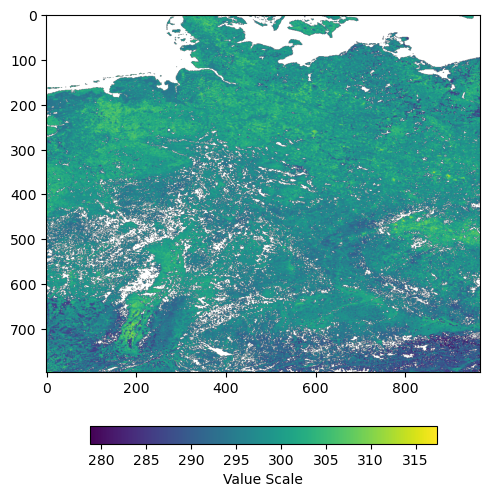

In [18]:
plotter(best_LST_maxLST)